In [103]:
from astropy.table import Table
from astropy.constants import c
from astropy.visualization.wcsaxes import SphericalCircle
from astropy import units as u

import numpy as np

import matplotlib.pyplot as plt

import pandas as pd

from tqdm import tqdm

## import data

In [37]:
loatable = Table.read('/pscratch/sd/d/dbustos/rot_curves/loa_targs_edited.fits')
loatable[:5]

TARGETID,TARGET_RA,TARGET_DEC,Z,ZERR,SPECTYPE,DELTACHI2,ZWARN,PVTYPE,SGA_ID,PHOTSYS,DIST,DIST_R26,Selection,bad_fiber
int64,float64,float64,float64,float64,bytes6,float64,int64,bytes3,int64,bytes1,float64,float64,int64,int64
2350675715424256,239.8472,31.7866,0.1492904161251356,1.9422911736100356e-05,GALAXY,5071.658419655636,0,TFT,483369,S,0.00018163397694836428,0.04183588292464746,1,0
2389103635070977,61.51249486530825,-17.766542165450435,0.2898542763769689,1.3051647863939431e-05,GALAXY,585.0907674431801,0,TFT,526821,S,0.015034501051441454,0.40000000781105455,1,0
2389161461940225,53.110693190838745,-15.204162701018703,1.41029052508368,0.00015282405234457233,GALAXY,2.055874802172184,4,TFT,431568,S,0.020469853344286103,0.4000000051000554,1,0
2389161461940226,53.133949122267566,-15.238404516460593,1.490823662797069,8.773021438224206e-05,GALAXY,17.411476522684097,0,TFT,431568,S,0.020469853344283147,0.4000000050999976,1,0
2389190650101761,49.636675196299485,-14.026544506699297,0.01713651665060884,2.0408204503181013e-05,GALAXY,56.60990794678219,0,TFT,1074364,S,0.0026515899552215774,0.40000000679324754,1,0


In [26]:
SGA = Table.read('/global/cfs/cdirs/cosmo/data/sga/2020/SGA-2020.fits', 'ELLIPSE')
SGA[:5]

SGA_ID,SGA_GALAXY,GALAXY,PGC,RA_LEDA,DEC_LEDA,MORPHTYPE,PA_LEDA,D25_LEDA,BA_LEDA,Z_LEDA,SB_D25_LEDA,MAG_LEDA,BYHAND,REF,GROUP_ID,GROUP_NAME,GROUP_MULT,GROUP_PRIMARY,GROUP_RA,GROUP_DEC,GROUP_DIAMETER,BRICKNAME,RA,DEC,D26,D26_REF,PA,BA,RA_MOMENT,DEC_MOMENT,SMA_MOMENT,G_SMA50,R_SMA50,Z_SMA50,SMA_SB22,SMA_SB22.5,SMA_SB23,SMA_SB23.5,SMA_SB24,SMA_SB24.5,SMA_SB25,SMA_SB25.5,SMA_SB26,G_MAG_SB22,R_MAG_SB22,Z_MAG_SB22,G_MAG_SB22.5,R_MAG_SB22.5,Z_MAG_SB22.5,G_MAG_SB23,R_MAG_SB23,Z_MAG_SB23,G_MAG_SB23.5,R_MAG_SB23.5,Z_MAG_SB23.5,G_MAG_SB24,R_MAG_SB24,Z_MAG_SB24,G_MAG_SB24.5,R_MAG_SB24.5,Z_MAG_SB24.5,G_MAG_SB25,R_MAG_SB25,Z_MAG_SB25,G_MAG_SB25.5,R_MAG_SB25.5,Z_MAG_SB25.5,G_MAG_SB26,R_MAG_SB26,Z_MAG_SB26,SMA_SB22_ERR,SMA_SB22.5_ERR,SMA_SB23_ERR,SMA_SB23.5_ERR,SMA_SB24_ERR,SMA_SB24.5_ERR,SMA_SB25_ERR,SMA_SB25.5_ERR,SMA_SB26_ERR,G_MAG_SB22_ERR,R_MAG_SB22_ERR,Z_MAG_SB22_ERR,G_MAG_SB22.5_ERR,R_MAG_SB22.5_ERR,Z_MAG_SB22.5_ERR,G_MAG_SB23_ERR,R_MAG_SB23_ERR,Z_MAG_SB23_ERR,G_MAG_SB23.5_ERR,R_MAG_SB23.5_ERR,Z_MAG_SB23.5_ERR,G_MAG_SB24_ERR,R_MAG_SB24_ERR,Z_MAG_SB24_ERR,G_MAG_SB24.5_ERR,R_MAG_SB24.5_ERR,Z_MAG_SB24.5_ERR,G_MAG_SB25_ERR,R_MAG_SB25_ERR,Z_MAG_SB25_ERR,G_MAG_SB25.5_ERR,R_MAG_SB25.5_ERR,Z_MAG_SB25.5_ERR,G_MAG_SB26_ERR,R_MAG_SB26_ERR,Z_MAG_SB26_ERR,G_COG_PARAMS_MTOT,G_COG_PARAMS_M0,G_COG_PARAMS_ALPHA1,G_COG_PARAMS_ALPHA2,G_COG_PARAMS_CHI2,R_COG_PARAMS_MTOT,R_COG_PARAMS_M0,R_COG_PARAMS_ALPHA1,R_COG_PARAMS_ALPHA2,R_COG_PARAMS_CHI2,Z_COG_PARAMS_MTOT,Z_COG_PARAMS_M0,Z_COG_PARAMS_ALPHA1,Z_COG_PARAMS_ALPHA2,Z_COG_PARAMS_CHI2,ELLIPSEBIT
int64,bytes16,bytes29,int64,float64,float64,bytes21,float32,float32,float32,float32,float32,float32,bool,bytes13,int64,bytes35,int16,bool,float64,float64,float32,bytes8,float64,float64,float32,bytes4,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int32
2,SGA-2020 2,PGC1283207,1283207,228.3770865,5.4232017,S?,152.2,0.36307806,0.724436,0.03463229,23.40448,16.976,False,LEDA-20181114,0,PGC1283207,1,True,228.3770865,5.4232017,0.36307806,2283p055,228.3770803831908,5.423191398593787,0.49470574,SB26,158.20142,0.545691,228.37700918822188,5.4232652570544015,10.897086,3.3509698,3.1147978,3.240862,5.902337,6.9126143,7.941369,8.997992,10.073601,11.199986,12.391357,13.561038,14.841172,16.966799,16.108246,15.486356,16.879545,16.024958,15.400715,16.818878,15.967034,15.341793,16.776297,15.925804,15.300776,16.746685,15.897334,15.272053,16.725166,15.876816,15.2521105,16.708357,15.862035,15.237181,16.696539,15.851936,15.226998,16.689613,15.844313,15.21976,0.013392451,0.02354,0.021872982,0.01736985,0.024445537,0.039866067,0.05026544,0.08455789,0.122911856,0.005682776,0.0054258136,0.0049038026,0.005588406,0.005323561,0.0047632363,0.00543534,0.005177031,0.0046343105,0.0053025587,0.005040888,0.0045181247,0.005206092,0.0049438984,0.0044374703,0.0051483097,0.0048758644,0.0043834248,0.0051032505,0.0048264163,0.004344248,0.0050705094,0.004792021,0.004319857,0.005054293,0.004765629,0.0043044444,16.65942,0.34037337,0.2978292,3.0239506,0.07928849,15.820566,0.2640441,0.34559453,3.3033552,0.003811298,15.195567,0.29826432,0.3001073,3.2333765,0.011723555,0
3,SGA-2020 3,PGC1310416,1310416,202.54443750000002,6.9345944,Sc,159.26,0.4017908,0.7816278,0.073888786,23.498482,16.85,False,LEDA-20181114,1,PGC1310416,1,True,202.54443750000002,6.9345944,0.4017908,

## Removing fibers and creating new table
Remove all points in loa['bad_fiber'] that have a 1

Ensure all galaxies remaining still fit criteria of </br>
a) 1 center pt + 2 unique points </br>
b) 2 symmetric points + 1 unique point </br>

In [40]:
#target distance that can be considered in center
#units R26
center_dist_lim = 0.001

#minimum distance between two targets to be considered unique
#units R26
unique_dist_lim = 0.01

In [46]:
#new table with no bad fibers
loa_goodfiber = loatable[loatable['bad_fiber']==0]

#ensure all galaxies still fit criteria

#for each unique SGA ID
for i in tqdm(np.unique(loa_goodfiber['SGA_ID'])):

    #identify all the galaxies and targets
    obs_id = np.logical_and(loa_goodfiber['SGA_ID'] == i, loa_goodfiber['TARGETID'] > 0)
    #logical_and returns if both statements are true
    
    #makes a table of the targets corresponding to this galaxy
    obs = loa_goodfiber[obs_id]

    sga_id = SGA_dict[i] 

#if the galaxy has more than three observations
    if len(obs) >= 3:

#-----
# a
#-----
        #check to see if there is a center observation
        if np.any(obs['DIST_R26'] < center_dist_lim):

            #since there is a center observation, check if there are two unique points
            not_center = obs[obs['DIST_R26'] > center_dist_lim]

            if len(not_center) >= 2 and (np.max(not_center['DIST_R26']) - np.min(not_center['DIST_R26'])) >= unique_dist_lim:

                #since there 2 unique points, classify it as viable galaxy
                loa_goodfiber['Selection'][obs_id] = 2
#----
# b
#----
        #since there isn't a center observation
        else:
            
            #split targets into above and below SGA declination
            if (SGA['PA'][sga_id] < 45) or (SGA['PA'][sga_id] > 135):

                left_index = obs['TARGET_DEC'] - SGA['DEC'][sga_id] > 0

            else:
                left_index = obs['TARGET_RA'] - SGA['RA'][sga_id] > 0
                
            left = obs[left_index]
            right = obs[~left_index]

            if len(left) > 0 and len(right) > 0:

                for j in range(len(left)):
                    
                    # check that there are 2 symmetric observations
                    if np.any(np.abs(right['DIST_R26'] - left['DIST_R26'][j]) < unique_dist_lim):

                    #check if there is a third point
                        if (np.any(np.abs(right['DIST_R26'] - left['DIST_R26'][j]) > unique_dist_lim)
                        or np.any(np.abs(left['DIST_R26'] - left['DIST_R26'][j]) > unique_dist_lim)):
                            
                            #viable galaxy
                            loa_goodfiber['Selection'][obs_id] = 2

print(len(loa_goodfiber[loa_goodfiber['Selection']==2]))
loa = (loa_goodfiber[loa_goodfiber['Selection']==2])
len(np.unique(loa['SGA_ID']))

100%|██████████| 1090/1090 [00:00<00:00, 1237.22it/s]

4240


706

In [47]:
SGA_dict = {}
for i in range(len(SGA)):
    SGA_dict[SGA['SGA_ID'][i]] = i

## calculate pv

This version takes the weighted average

In [127]:
loa['Velocity'] = np.nan
loa['V_err'] = np.nan
loa['Z_center'] = np.nan
loa['c_or_s'] = 0

for i in tqdm(np.unique(loa['SGA_ID'])[:12]):
    fiber = loa['SGA_ID'] == i 
    
    # find z and its error for all targets
    z_targ = loa['Z'][fiber]
    z_e = loa['ZERR'][fiber]

    #check if there is a center fiber
    if np.any(loa['DIST_R26'][fiber] < center_dist_lim):
        
        # find all center fibers
        criteria = (loa['DIST_R26'][fiber] < .001) & (loa['ZWARN'][fiber] == 0) & (loa['DELTACHI2'][fiber] > 25)
        center = loa[fiber][criteria]

        # find z for center targets
        z_c = center['Z']

        # calculate weight of center targets
        zc_err = center['ZERR']
        weight = np.sum(1/ (zc_err**2))

    #since there isn't a center fiber, find the redshift at the center given two symmetric points
    else:
        #mark as 1 (symmetric)
        loa['c_or_s'][np.where(fiber)] = 1

        obs = loa[fiber]

        sga_id = SGA_dict[i]

        #create empty table of symmetric left and right
        symmetric_right, symmetric_left = [], []
        
        #split targets into above and below SGA declination
        if (SGA['PA'][sga_id] < 45) or (SGA['PA'][sga_id] > 135):

            left_index = loa['TARGET_DEC'][fiber] - SGA['DEC'][sga_id] > 0

        else:
            left_index = loa['TARGET_RA'][fiber] - SGA['RA'][sga_id] > 0

        left, right = obs[left_index], obs[~left_index]

        #find R26 for each fiber
        right_dist, left_dist = np.array(right['DIST_R26']), np.array(left['DIST_R26'])

        #create a matrix subtracting each right element from each left element
        diff_matrix = np.abs(right_dist[:,np.newaxis]-left_dist)

        #identify all points in matrix where difference is within unique dist (fibers are symmetric)
        right_idx, left_idx = np.where(diff_matrix < unique_dist_lim)

        #put those rows into appropriate tables
        #symmetric_right, symmetric_left = right[np.unique(right_idx)], left[np.unique(left_idx)]

        symmetric_right = right[np.unique(right_idx)].to_pandas()
        identical_rows = symmetric_right[symmetric_right.duplicated(subset=['DIST_R26'], keep=False)]

        #df = pd.DataFrame(symmetric_right, columns = ['DIST_R26','Z'])
        #identical_rows = df[df.duplicated(subset = ['DIST_R26'], keep = False)]
identical_rows
        
        # #take the z and z_err
        # if (len(symmetric_right)==1):
        #     z_right = symmetric_right['Z']
        # else:
        #     dist, counts = np.unique(symmetric_right['DIST_R26'], return_counts = True)
        #     criteria = (symmetric_right['ZWARN'] == 0) & (symmetric_right['DELTACHI2'] > 25)

        #     for d in dist[counts>1]:
        #         group = (symmetric_right['DIST_R26'] == d) & criteria 

        #         if np.any(group):
        #             z_right[d] = np.mean(symmetric_right['Z'][group])
        #         else:
        #             z_right[d] = np.nan


        # if (len(symmetric_left)==1):
        #     z_left = symmetric_left['Z']
        # else:
        #     z_left = {}
        #     dist, counts = np.unique(symmetric_left['DIST_R26'], return_counts = True)
        #     criteria = (symmetric_left['ZWARN'] == 0) & (symmetric_left['DELTACHI2'] > 25)

        #     for d in dist[counts>1]:
        #         group = (symmetric_left['DIST_R26'] == d) & criteria 

        #         if np.any(group):
        #             z_right[d] = np.mean(symmetric_left['Z'][group])
        #         else:
        #             z_right[d] = np.nan

    #     z_right_err = symmetric_right['ZERR']
    #     z_left_err = symmetric_left['ZERR']

    #     #calculate z_center and weight for each pair
    #     min_len = min(len(z_left),len(z_right))
    #     z_c = (np.array(z_right)+np.array(z_left))/2
    #     weight = np.sum(1/(z_right_err**2)) + np.sum(1/(z_left_err**2))

    # #take weighted average of z_cen
    # z_cen = (np.mean(weight*z_c))/weight

    # z_cen_err = np.sqrt(1/weight)

    # # find the redshift of each fiber relative to the center
    # z_rel = (1 + z_targ)/(1 + z_cen) - 1

    # # find the peculiar velocity
    # velocity = z_rel * (c.to('km/s'))

    # v_error = c*np.sqrt((z_cen_err**2)+(z_e**2))

    # # add all this information to a table
    # loa['Velocity'][fiber] = velocity  

    # loa['V_err'][fiber] = v_error
    
    # loa['Z_center'][fiber] = z_cen_err

100%|██████████| 12/12 [00:00<00:00, 681.73it/s]


,TARGETID,TARGET_RA,TARGET_DEC,Z,ZERR,SPECTYPE,DELTACHI2,ZWARN,PVTYPE,SGA_ID,PHOTSYS,DIST,DIST_R26,Selection,bad_fiber,Velocity,V_err,Z_center,c_or_s
0,2389816142462976,190.225052,11.895545,0.524701,0.000051,b'GALAXY',4.650791,4,b'TFT',20404,b'S',0.021873,0.4,2,0,NaN,NaN,NaN,1
1,2403010281996288,190.225052,11.895545,1.013993,0.000226,b'GALAXY',3.470233,4,b'TFT',20404,b'S',0.021873,0.4,2,0,NaN,NaN,NaN,1
2,2842814933106688,190.225052,11.895545,0.063936,0.000052,b'GALAXY',4.311753,4,b'TFT',20404,b'S',0.021873,0.4,2,0,NaN,NaN,NaN,1


In [ ]:
for i in symmetric_right:
    if np.any(symmetric_right['DIST_R26']==symmetric_right['DIST_R26'][i]):
        criteria = (symmetric_right['ZWARN'][fiber] == 0) & (symmetric_right['DELTACHI2'][fiber] > 25)
            z_right = np.mean(symmetric_right['Z'][criteria])

In [30]:
loa[4]

TARGETID,TARGET_RA,TARGET_DEC,Z,ZERR,SPECTYPE,DELTACHI2,ZWARN,PVTYPE,SGA_ID,PHOTSYS,DIST,DIST_R26,Selection,bad_fiber,Velocity,V_err,Z_center,c_or_s
int64,float64,float64,float64,float64,bytes6,float64,int64,bytes3,int64,bytes1,float64,float64,int64,int64,float64,float64,float64,int64
2389190650101761,49.636675196299485,-14.026544506699297,0.01713651665060884,2.0408204503181013e-05,GALAXY,56.60990794678219,0,TFT,1074364,S,0.0026515899552215774,0.40000000679324754,1,0,nan,nan,nan,1


In [93]:
loa[loa['SGA_ID']==13054]

TARGETID,TARGET_RA,TARGET_DEC,Z,ZERR,SPECTYPE,DELTACHI2,ZWARN,PVTYPE,SGA_ID,PHOTSYS,DIST,DIST_R26,Selection,bad_fiber,Velocity,V_err,Z_center,c_or_s
int64,float64,float64,float64,float64,bytes6,float64,int64,bytes3,int64,bytes1,float64,float64,int64,int64,float64,float64,float64,int64
2402914647670784,166.98264808769204,8.01086656056278,0.010925423799486961,7.630187485572665e-06,GALAXY,441.24300627061166,0,TFT,13054,S,0.0098783392061301,0.40000000945108866,1,0,-61.80416765515617,2335.659623039069,1.5743896619644768e-06,1
2402914647670785,166.989664609059,7.992372001157544,0.01134285644455157,2.4405576344280983e-06,GALAXY,3285.101432479918,0,TFT,13054,S,0.00987833920611997,0.40000000945067843,1,0,61.96100501795415,870.6906361907345,1.5743896619644768e-06,1
2407312694181889,166.99141863996982,7.987748343693714,1.4724935650286013,0.00016348918139905036,GALAXY,0.02547098696231842,4,EXT,13054,S,0.014817507982418416,0.5999999806982623,1,0,433280.5218613499,49015.09611179745,1.5743896619644768e-06,1
2842719298781184,166.98264808769204,8.01086656056278,0.010921676153653635,5.706055825853058e-06,GALAXY,685.0019019469619,0,TFT,13054,S,0.0098783392061301,0.40000000945108866,1,0,-62.915312265317965,1774.5529729331201,1.5743896619644768e-06,1
2842719298781185,166.989664609059,7.992372001157544,0.011345546134680905,2.308426994564072e-06,GALAXY,3642.890012703836,0,TFT,13054,S,0.00987833920611997,0.40000000945067843,1,0,62.75847490261984,837.6792469631664,1.5743896619644768e-06,1
2847117345292292,166.99317263115657,7.983124678251825,1.550587789564711,0.00011638414615649606,GALAXY,2.9745779931545258,4,EXT,13054,S,0.01975667730989449,0.799999974264482,1,0,456434.7847077266,34894.281532142144,1.5743896619644768e-06,1
2847117345292296,166.99492658264336,7.978501005425158,0.6358557701447967,0.00011182463740472864,GALAXY,0.47511182457674295,4,EXT,13054,S,0.024695846637374504,0.9999999678308613,1,0,185224.64416971078,33527.50534487694,1.5743896619644768e-06,1


## velocity map

100%|██████████| 1/1 [00:00<00:00, 41.35it/s]


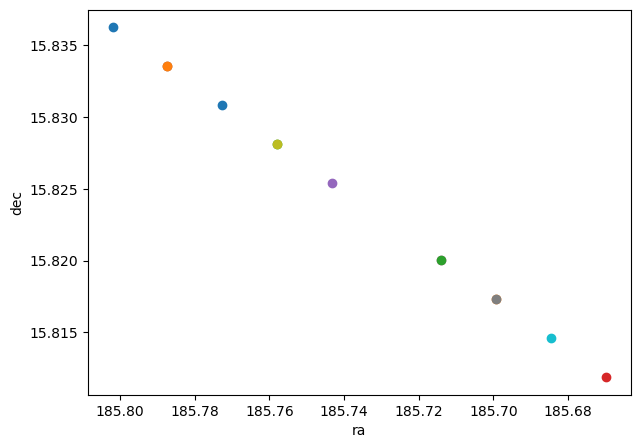

In [33]:
# for each rotation curve galaxy, grab cut out, draw fibers on image, and save image
for sga_id in tqdm(np.unique(loa['SGA_ID'])[3:4]):
    
    targ_list = loa[loa['SGA_ID']==sga_id]

    fig1 = plt.figure(figsize=(7,5))

    ax = fig1.add_subplot()
    ax.set(xlabel='ra', ylabel='dec')

    for targ in targ_list:
        ra, dec = targ['TARGET_RA'], targ['TARGET_DEC']
        
        ax.scatter(ra,dec)
        ax.invert_xaxis()

## Test

In [50]:
loa['Velocity'] = np.nan
loa['V_err'] = np.nan
loa['Z_center'] = np.nan
loa['c_or_s'] = 0

for i in tqdm(np.unique(loa['SGA_ID'])[:10]):
    fiber = loa['SGA_ID'] == i 
    
    # find z and its error for all targets
    z_targ = loa['Z'][fiber]
    z_e = loa['ZERR'][fiber]

    #check if there is a center fiber
    if np.any(loa['DIST_R26'][fiber] < center_dist_lim):
        # find all center fibers
        criteria = (loa['DIST_R26'][fiber] < .001) & (loa['ZWARN'][fiber] == 0) & (loa['DELTACHI2'][fiber] > 25)
        center = loa[fiber][criteria]

        # find z for center targets
        z_c = center['Z']

        # calculate weight of center targets
        zc_err = center['ZERR']
        weight = np.sum(1/ (zc_err**2))

    #since there isn't a center fiber, find the redshift at the center given two symmetric points
    else:
        #mark as 1 (symmetric)
        loa['c_or_s'] = 1

        obs = loa[fiber]

        sga_id = SGA_dict[i]

        #create empty table of symmetric left and right
        symmetric_right = []

        symmetric_left = []
        
        #split targets into above and below SGA declination
        if (SGA['PA'][sga_id] < 45) or (SGA['PA'][sga_id] > 135):

            left_index = loa['TARGET_DEC'][fiber] - SGA['DEC'][sga_id] > 0

        else:
            left_index = loa['TARGET_RA'][fiber] - SGA['RA'][sga_id] > 0

        left = obs[left_index]
        right = obs[~left_index]

        #find R26 for each fiber
        right_dist = np.array(right['DIST_R26'])
        left_dist = np.array(left['DIST_R26'])

        #create a matrix subtracting each right element from each left elemetn
        diff_matrix = np.abs(right_dist[:,np.newaxis]-left_dist)

        #identify all points in matrix where difference is within unique dist (fibers are symmetric)
        right_idx, left_idx = np.where(diff_matrix < unique_dist_lim)

        #put those rows into appropriate tables
        symmetric_right = right[np.unique(right_idx)]
        symmetric_left = left[np.unique(left_idx)]
        
        #take the z and z_err
        z_right = symmetric_right['Z']
        z_left = symmetric_left['Z']

        z_right_err = symmetric_right['ZERR']
        z_left_err = symmetric_left['ZERR']

        #calculate z_center and weight for each pair
        min_len = min(len(z_left),len(z_right))
        z_c = (z_right[:min_len]+z_left[:min_len])/2
        weight = np.sum(1/(z_right_err**2)) + np.sum(1/(z_left_err**2))

    #take weighted average of z_cen
    z_cen = (np.mean(weight*z_c))/weight

    z_cen_err = np.sqrt(1/weight)

    # find the redshift of each fiber relative to the center
    z_rel = (1 + z_targ)/(1 + z_cen) - 1

    # find the peculiar velocity
    velocity = z_rel * (c.to('km/s'))

    v_error = c*np.sqrt((z_cen_err**2)+(z_e**2))

    # add all this information to a table
    loa['Velocity'][fiber] = velocity  

    loa['V_err'][fiber] = v_error
    
    loa['Z_center'][fiber] = z_cen_err

100%|██████████| 10/10 [00:00<00:00, 623.21it/s]


In [40]:
#this works if there is a fiber in the center
for i in tqdm(np.unique(loa['SGA_ID'])[:10]):

    # identify all fibers
    fiber = loa['SGA_ID'] == i
    
    # find all center fibers
    criteria = (loa['DIST_R26'][fiber] < .001) & (loa['ZWARN'][fiber] == 0) & (loa['DELTACHI2'][fiber] > 25)
    center = loa[fiber][criteria]

    # find z and its error for all targets
    z_targ = loa['Z'][fiber]
    z_e = loa['ZERR'][fiber]

    # find z for center targets
    z_c = center['Z']

    # calculate weight of center targets
    zc_err = center['ZERR']
    weight = np.sum(1/ (zc_err**2))

    # weighted z and error
    data = weight*z_c
    if np.isnan(data).all():
        z_cen = np.nan
    else:
        z_cen = (np.nanmean(data))/weight
        
    z_cen_err = np.sqrt(1/np.where(weight==0,np.nan,weight))

    # find the redshift of each fiber relative to the center
    z_rel = ((1 + z_targ)/(1 + z_cen) - 1)

    velocity = np.array(z_rel) * c.to('km/s')

    v_error = c*np.sqrt((z_cen_err**2)+(z_e**2))

    print(v_error)


100%|██████████| 10/10 [00:00<00:00, 786.23it/s]

[656.78391852 563.14919355 667.09095146] m / s
[nan nan nan nan] m / s
[nan nan nan nan] m / s
[nan nan nan nan nan nan nan nan nan nan nan nan nan] m / s
[nan nan nan] m / s
[29712.72446691 27230.84319822 24542.19920273] m / s
[nan nan nan nan] m / s
[nan nan nan] m / s
[811.27360889 902.2491284  732.94479231] m / s
[35844.61244793 32453.3255831   3360.59511235] m / s


In [17]:
for i in tqdm(np.unique(loa['SGA_ID'])[:3]):
    fiber = loa['SGA_ID'] == i 

    #check if there is a center fiber
    if np.any(loa['DIST_R26'][fiber] < .001):
        continue

    #since there isn't a center fiber, find the redshift at the center given two symmetric points
    else:

        obs = loa[fiber]

        sga_id = SGA_dict[i]

        symmetric_right = []

        symmetric_left = []
        
        #split targets into above and below SGA declination
        if (SGA['PA'][sga_id] < 45) or (SGA['PA'][sga_id] > 135):

            left_index = loa['TARGET_DEC'][fiber] - SGA['DEC'][sga_id] > 0

        else:
            left_index = loa['TARGET_RA'][fiber] - SGA['RA'][sga_id] > 0
                
        left = obs[left_index]
        right = obs[~left_index]

        right_dist = np.array(right['DIST_R26'])
        left_dist = np.array(left['DIST_R26'])

        diff_matrix = np.abs(right_dist[:,np.newaxis]-left_dist)

        right_index, left_index = np.where(diff_matrix < unique_dist_lim)

        symmetric_right=right[np.unique(right_index)]
        symmetric_left=left[np.unique(left_index)]

        z_right = symmetric_right['Z']
        z_left = symmetric_left['Z']

        z_right_err = symmetric_right['ZERR']
        z_left_err = symmetric_left['ZERR']

        z_center = (z_right+z_left)/2
        weight = np.sum(1/(z_right_err**2)) + np.sum(1/(z_left_err**2))

        z_cen = (np.nanmean(weight*z_center))/weight

        z_cen_err = np.sqrt(1/np.where(weight==0,np.nan,weight))
        

z_center
symmetric_right
z_cen
        # for j in range(len(left)): 
        #      for k in range(len(right)):

        #         index = np.where(np.abs(right['DIST_R26'][k] - left['DIST_R26'][j]) < unique_dist_lim)

        #         symmetric_right = right[index]
        #         symmetric_left = left[index]

#         for j in range(len(left)): 
#             for k in range(len(right)):

#                 right_index, left_index = np.where(np.abs(right['DIST_R26'][k] - left['DIST_R26'][j]) < unique_dist_lim)
                
#                 # if (np.abs(right['DIST_R26'][k] - left['DIST_R26'][j]) < unique_dist_lim):
                
#                 #     symmetric_right.append(right)
#                 #     symmetric_left.append(left)

#                     # z_right = symmetric_right['Z']
#                     # z_left = symmetric_left['Z']
# symmetric_right
#                     # z_center = (z_right+z_left)/2
#                     # zcr_err = symmetric_right['ZERR']
#                     # zcl_err = symmetric_left['ZERR']              

100%|██████████| 3/3 [00:00<00:00, 800.64it/s]


np.float64(0.005768517498550757)

In [359]:
loa[loa['SGA_ID']==20404]

TARGETID,TARGET_RA,TARGET_DEC,Z,ZERR,SPECTYPE,DELTACHI2,ZWARN,PVTYPE,SGA_ID,PHOTSYS,DIST,DIST_R26,Selection,bad_fiber
int64,float64,float64,float64,float64,bytes6,float64,int64,bytes3,int64,bytes1,float64,float64,int64,int64
2389816142462976,190.22505182620995,11.895545294175658,0.524701332062387,5.083744660140211e-05,GALAXY,4.650790706276894,4,TFT,20404,S,0.021873046154446407,0.3999999926363773,1,0
2389816142462977,190.25469115897948,11.9282967507748,0.10673715136125288,6.266442371591254e-05,GALAXY,3.882690606173128,4,TFT,20404,S,0.02187304615441451,0.399999992635794,1,0
2394214184779778,190.21023483767897,11.879168405837207,0.5871825868605388,5.032644661263963e-05,GALAXY,7.178346291184425,4,EXT,20404,S,0.04374609230892866,0.7999999852734102,1,0
2403010281996288,190.22505182620995,11.895545294175658,1.0139926000380255,0.0002256328598334778,GALAXY,3.4702329710125923,4,TFT,20404,S,0.021873046154446407,0.3999999926363773,1,0
2407408328507397,190.24728065549252,11.920109177006209,0.005304194182023052,4.116195443812506e-05,GALAXY,640.5681047043072,0,EXT,20404,S,0.010936523077214464,0.19999999631802884,1,0
2842814933106688,190.22505182620995,11.895545294175658,0.063935842143866,5.189458355975261e-05,GALAXY,4.311753127956763,4,TFT,20404,S,0.021873046154446407,0.3999999926363773,1,0
2842814933106689,190.25469115897948,11.9282967507748,0.5607058395338489,0.00010731128208168081,GALAXY,3.227832432836294,4,TFT,20404,S,0.02187304615441451,0.399999992635794,1,0
2847207061454848,190.20282701171357,11.87097967217817,0.25330670860501336,4.003075776206705e-05,GALAXY,8.617242198437452,4,EXT,20404,S,0.05468261538618574,0.9999999815922184,1,0
2847212979617794,190.21764310906696,11.887356946552542,1.2097943053676932,0.00011141568021813813,GALAXY,0.5635000579059124,4,EXT,20404,S,0.03280956923170088,0.5999999889551378,1,0


In [338]:
for i in tqdm(np.unique(loa['SGA_ID'])[:3]):
    fiber = loa['SGA_ID'] == i 

    #check if there is a center fiber
    if np.any(loa['DIST_R26'][fiber] < .001):
        continue

    #since there isn't a center fiber, find the redshift at the center given two symmetric points
    else:

        obs = loa[fiber]

        sga_id = SGA_dict[i]

        symmetric_right = []

        symmetric_left = []
        
        #split targets into above and below SGA declination
        if (SGA['PA'][sga_id] < 45) or (SGA['PA'][sga_id] > 135):

            left_index = loa['TARGET_DEC'][fiber] - SGA['DEC'][sga_id] > 0

        else:
            left_index = loa['TARGET_RA'][fiber] - SGA['RA'][sga_id] > 0
                
        left = obs[left_index]
        right = obs[~left_index]

        for j in range(len(left)): 
            for k in range(len(right)):

                symmetry = np.abs(right['DIST_R26'][k] - left['DIST_R26'][j]) 
                symmetric_right = right[np.where(symmetry<unique_dist_lim)]
symmetric_right
                    # z_right = symmetric_right['Z']
                    # z_left = symmetric_left['Z']
                    
                    # z_center = (z_right+z_left)/2
                    # zcr_err = symmetric_right['ZERR']
                    # zcl_err = symmetric_left['ZERR'] 
                    # weight = (1/zcr_err**2)+(1/zcl_err**2)


 33%|███▎      | 1/3 [00:00<00:00, 835.35it/s]


ValueError: Calling nonzero on 0d arrays is not allowed. Use np.atleast_1d(scalar).nonzero() instead. If the context of this error is of the form `arr[nonzero(cond)]`, just use `arr[cond]`.